
# Object Detection Metrics: Precision, Recall, IoU, F1 Score, and mAP

În acest notebook, vom explora principalele metrici utilizate pentru evaluarea performanței modelelor de detecție a obiectelor. Vom folosi exemple sintetice pentru a înțelege cum se calculează și interpretează aceste metrici.



## 📏 Definiții ale metricilor

- **Precision**: Proporția detecțiilor corecte din totalul detecțiilor efectuate.
  $ 	\text{Precision} = \frac{TP}{TP + FP} $

- **Recall**: Proporția obiectelor reale detectate corect.
  $	\text{Recall} = \frac{TP}{TP + FN} $

- **IoU (Intersection over Union)**: Măsoară suprapunerea dintre bounding box-ul prezis și cel real.
  $ 	\text{IoU} = \frac{	\text{Aria Intersecției}}{	\text{Aria Uniunii}} $

- **F1 Score**: Media armonică între precision și recall.
  $ F1 = 2 \cdot \frac{	\text{Precision} \cdot 	\text{Recall}}{	\text{Precision} + 	\text{Recall}} $

- **mAP (mean Average Precision)**: Media valorilor de precision pentru diferite praguri de IoU și clase.


In [7]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


In [4]:

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea)
    return iou


IoU: 0.64


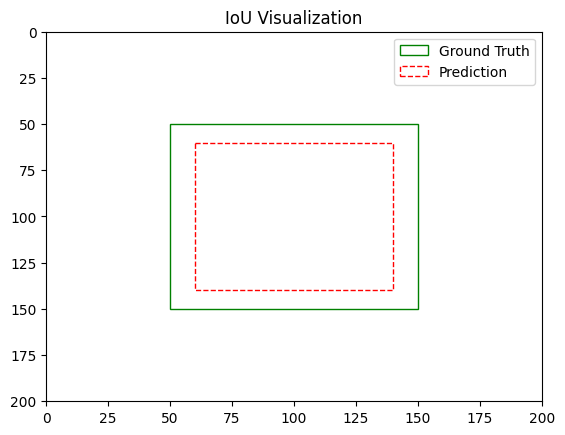

In [8]:

# Ground truth and predicted bounding boxes
# Format: [x1, y1, x2, y2]
gt_box = [50, 50, 150, 150]
pred_box = [60, 60, 140, 140]

# Compute IoU
iou = compute_iou(gt_box, pred_box)
print(f"IoU: {iou:.2f}")

# Visualize
fig, ax = plt.subplots()
ax.add_patch(Rectangle((gt_box[0], gt_box[1]), gt_box[2]-gt_box[0], gt_box[3]-gt_box[1], edgecolor='g', facecolor='none', label='Ground Truth'))
ax.add_patch(Rectangle((pred_box[0], pred_box[1]), pred_box[2]-pred_box[0], pred_box[3]-pred_box[1], edgecolor='r', facecolor='none', linestyle='--', label='Prediction'))
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.legend()
plt.gca().invert_yaxis()
plt.title("IoU Visualization")
plt.show()


In [9]:

def compute_metrics(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

# Exemplu: 8 detecții corecte, 2 greșite, 4 ratate
tp, fp, fn = 8, 2, 4
precision, recall, f1 = compute_metrics(tp, fp, fn)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1:.2f}")


Precision: 0.80, Recall: 0.67, F1 Score: 0.73



## 🧠 Ce este mAP?

Pentru fiecare clasă, se calculează o curbă Precision-Recall. Apoi se calculează aria de sub această curbă (AP - Average Precision). mAP este media acestor valori pentru toate clasele.

În practică, se folosește adesea mAP@0.5 (IoU ≥ 0.5) sau mAP@[.5:.95] (media pentru praguri între 0.5 și 0.95).
